In [ ]:
import sys
from pathlib import Path
from datetime import datetime

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import (
    AUGMENTATION_FIGURES_DIR,
    DATA_PATH,
    PREDICTION_FIGURES_DIR,
    RESULTS_DIR,
    RUNS_DIR,
    SHAP_FIGURES_DIR,
    SHAP_SCATTER_FIGURES_DIR,
    TABLES_DIR,
)

for directory in [
    RESULTS_DIR,
    PREDICTION_FIGURES_DIR,
    AUGMENTATION_FIGURES_DIR,
    SHAP_FIGURES_DIR,
    SHAP_SCATTER_FIGURES_DIR,
    TABLES_DIR,
    RUNS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

SYNTHESIZER_METHOD = "CUSTOM_GAN"
RUN_AUGMENTATION = True
INITIAL_SAMPLES = 10000
AUGMENTATION_RATIOS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]


In [ ]:
from sklearn.model_selection import train_test_split

from src.config import N_FEATURES, RANDOM_STATE, TEST_SIZE
from src.data_process import DataHandler

data_handler = DataHandler(DATA_PATH, n_features=N_FEATURES)
data_handler.load_data()

original_df = data_handler.data_df
target_col = data_handler.target_name
X = data_handler.X
y = data_handler.y

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f"Data path: {DATA_PATH}")
print(f"Original data shape: {original_df.shape}")
print(f"Feature matrix shape: {X.shape}")
print(f"Target column: {target_col}")
print(f"Train samples: {len(x_train)}, test samples: {len(x_test)}")


In [ ]:
import matplotlib.pyplot as plt

from src.model_train import train_xgboost
from src.plotter import DataPlotter

baseline_result = train_xgboost(x_train, y_train, x_test, y_test)

plotter = DataPlotter()
fig, ax = plotter.plot(
    y_train,
    baseline_result.y_train_pred,
    y_test,
    baseline_result.y_test_pred,
    baseline_result.metrics["train"]["r2"],
    baseline_result.metrics["test"]["r2"],
)

baseline_figure_path = PREDICTION_FIGURES_DIR / f"baseline_prediction_{RUN_ID}.png"
fig.savefig(baseline_figure_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Baseline model: XGBoost")
print("Train metrics:", baseline_result.metrics["train"])
print("Test metrics:", baseline_result.metrics["test"])
print(f"Saved baseline figure: {baseline_figure_path}")


In [27]:
from src.data_augmentation import DataAugmentor

augmentor = DataAugmentor(baseline_model=baseline_result.model)

synthesizer_kwargs = {}
if SYNTHESIZER_METHOD.upper() in {"CUSTOM_GAN", "CUSTOMGAN", "GAN"}:
    synthesizer_kwargs = {
        "noise_dim": 32,
        "generator_hidden_dims": (256, 256),
        "discriminator_hidden_dims": (128, 64),
        "dropout": 0.2,
        "learning_rate": 2e-4,
        "device": "cuda",
    }

augmentor.fit_generator(
    full_df=original_df,
    method=SYNTHESIZER_METHOD,
    epochs=500,
    batch_size=256,
    verbose=True,
    **synthesizer_kwargs,
)


开始训练 CUSTOM_GAN 生成模型（epochs=500）on full data...
Epoch 0001/500: d_loss=1.3519, g_loss=0.6884
Epoch 0050/500: d_loss=1.3817, g_loss=0.7884
Epoch 0100/500: d_loss=1.4025, g_loss=0.6616
Epoch 0150/500: d_loss=1.4168, g_loss=0.6569
Epoch 0200/500: d_loss=1.4105, g_loss=0.6914
Epoch 0250/500: d_loss=1.3774, g_loss=0.6985
Epoch 0300/500: d_loss=1.4165, g_loss=0.6595
Epoch 0350/500: d_loss=1.3833, g_loss=0.6977
Epoch 0400/500: d_loss=1.3785, g_loss=0.7077
Epoch 0450/500: d_loss=1.3445, g_loss=0.7325
Epoch 0500/500: d_loss=1.4041, g_loss=0.6811
生成模型训练完成！总耗时: 0 分 24.68 秒


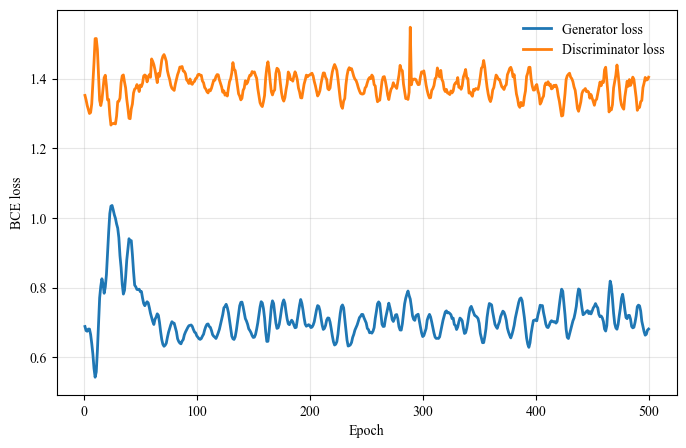

Saved GAN loss curve: D:\BaiduSyncdisk\pytorch\geopolymer-concrete-ml-pipeline\results\figures\augmentation\gan_loss_custom_gan_20260811_233420.png


In [28]:
loss_history = augmentor.generator.loss_history
epochs_axis = range(1, len(loss_history["generator"]) + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs_axis, loss_history["generator"], label="Generator loss", linewidth=2)
ax.plot(epochs_axis, loss_history["discriminator"], label="Discriminator loss", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE loss")
ax.legend(frameon=False)
ax.grid(alpha=0.3)

gan_loss_path = AUGMENTATION_FIGURES_DIR / f"gan_loss_{SYNTHESIZER_METHOD.lower()}_{RUN_ID}.png"
fig.savefig(gan_loss_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved GAN loss curve: {gan_loss_path}")


In [ ]:
syn_data = augmentor.generate_and_predict(
    initial_samples=INITIAL_SAMPLES,
    target_col=target_col,
)

syn_pool_path = TABLES_DIR / f"synthetic_pool_{SYNTHESIZER_METHOD.lower()}_{RUN_ID}.csv"
syn_data.to_csv(syn_pool_path, index=False)

print(f"Synthetic pool shape: {syn_data.shape}")
print(f"Saved synthetic pool: {syn_pool_path}")


In [ ]:
lgb_params_for_aug = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 128,
    "verbosity": -1,
}

aug_results = augmentor.run_augmentation_experiment(
    original_df=original_df,
    ratios=AUGMENTATION_RATIOS,
    target_col=target_col,
    lgb_params=lgb_params_for_aug,
    syn_data=syn_data,
)

augmentation_table_path = TABLES_DIR / f"augmentation_experiment_{SYNTHESIZER_METHOD.lower()}_{RUN_ID}.csv"
aug_results.to_csv(augmentation_table_path, index=False)

fig, ax = plotter.plot_aug_results_rmse(
    aug_results,
    ylabel="RMSE (MPa)",
    label=SYNTHESIZER_METHOD,
    save_path=str(AUGMENTATION_FIGURES_DIR / f"augmentation_rmse_{SYNTHESIZER_METHOD.lower()}_{RUN_ID}.png"),
)
plt.show()
plt.close(fig)

display(aug_results)
print(f"Saved augmentation results: {augmentation_table_path}")


Computing SHAP values...


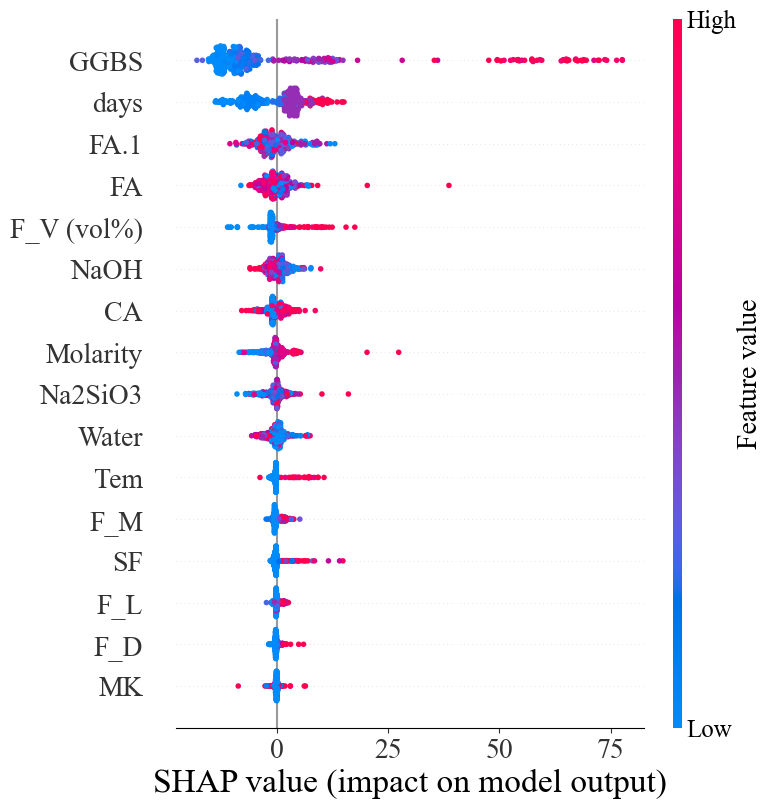

SHAP shape: (462, 16)
Saved SHAP summary: D:\BaiduSyncdisk\pytorch\geopolymer-concrete-ml-pipeline\results\figures\shap\shap_summary_20260811_233420.png


In [30]:
import pandas as pd

from src.shap_analysis import compute_shap_values

x_test_df = pd.DataFrame(x_test, columns=data_handler.feature_names)

print("Computing SHAP values...")
shap_values = compute_shap_values(baseline_result.model, x_test_df, check_additivity=False)

shap_summary_path = SHAP_FIGURES_DIR / f"shap_summary_{RUN_ID}.png"
fig, ax = plotter.plot_shap_summary(
    shap_values,
    x_test_df,
    save_path=str(shap_summary_path),
)
plt.show()
plt.close(fig)

print(f"SHAP shape: {shap_values.values.shape}")
print(f"Saved SHAP summary: {shap_summary_path}")


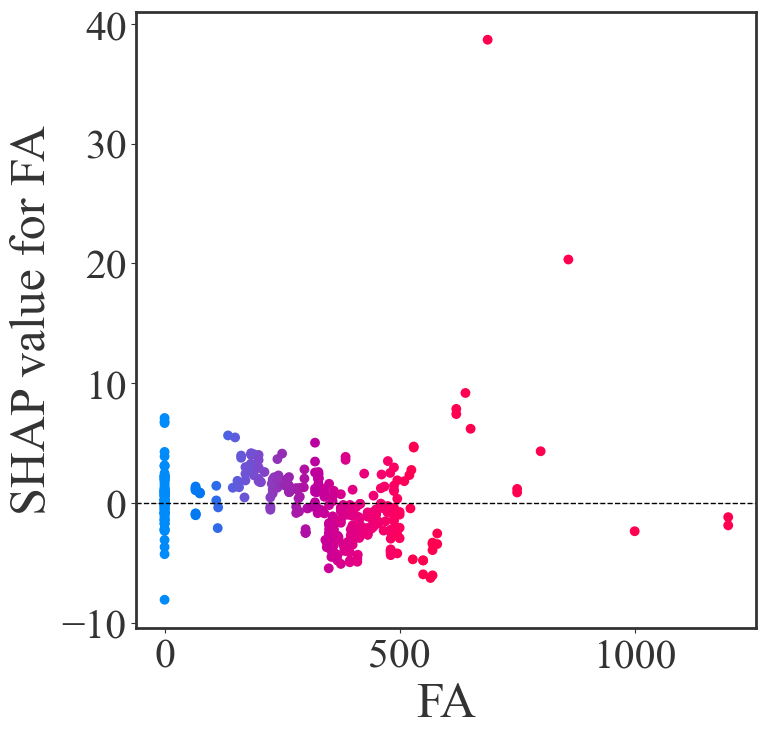

Saved SHAP scatter: D:\BaiduSyncdisk\pytorch\geopolymer-concrete-ml-pipeline\results\figures\shap\scatter\shap_scatter_feature_0_20260811_233420.png


In [26]:
feature_to_plot = 0

shap_scatter_path = SHAP_SCATTER_FIGURES_DIR / f"shap_scatter_feature_{feature_to_plot}_{RUN_ID}.png"
fig, ax = plotter.plot_shap_scatter_one(
    shap_values=shap_values,
    x_data=x_test_df,
    feature=feature_to_plot,
    point_size=50,
    save_path=str(shap_scatter_path),
)
plt.show()
plt.close(fig)

print(f"Saved SHAP scatter: {shap_scatter_path}")
